# Modelling: LSTM

This notebook reproduces the exact train/validation/test split from `04_modelling_classical.ipynb` and trains an LSTM on the cleaned `text` column only, as the deep-learning comparison point required by `PIPELINE.md`. Whether this model or the classical model is ultimately deployed is decided in `06_evaluation.ipynb` from held-out test-set performance, not decided here.

No metadata columns, no test-set evaluation, and no saved model artifact happen in this notebook. The test set stays untouched until `06_evaluation.ipynb`, which is also where the winning pipeline gets persisted.

In [1]:
# Standard library
import sys

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# Use the seaborn whitegrid theme for every chart, matching 03_eda.ipynb
sns.set_theme(style="whitegrid")

# Show every column when previewing a DataFrame, rather than truncating with "..."
pd.set_option("display.max_columns", None)

# Make the repository root importable so src/ can be reached from notebooks/
sys.path.append("..")

# A fixed seed reused from 04_modelling_classical.ipynb so this notebook reproduces the
# exact same train/validation/test split. TensorFlow and numpy are also seeded, though
# GPU-backed operations can still introduce their own nondeterminism even with a fixed
# seed (the same kind of floating-point nondeterminism already seen with GridSearchCV's
# n_jobs=-1 in 04_modelling_classical.ipynb); training here assumes a CPU-only run.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## Load the Cleaned Dataset

The dataset produced by `02_data_preparation.ipynb` is loaded and its shape is checked to confirm it still matches the eleven columns and 17,880 rows already confirmed in `04_modelling_classical.ipynb`.

In [2]:
# Load the cleaned dataset and report its shape
df = pd.read_csv("../data/processed/cleaned.csv")
print(df.shape)

(17880, 11)


## Reproduce the Train/Validation/Test Split

The same two `train_test_split` calls used in `04_modelling_classical.ipynb` are repeated here, unchanged, with the same `RANDOM_STATE`. This produces the identical training, validation, and test rows as notebook 04, so the two models are compared on the same data. Only the `text` column and the `fraudulent` label are used from here on — the LSTM does not see the metadata columns the classical models use.

In [3]:
# Separate the features from the label
X = df.drop(columns=["fraudulent"])
y = df["fraudulent"]

# First split: 70% train, 30% held out for validation and test combined
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

# Second split: the 30% holdout is split evenly into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_holdout, y_holdout, test_size=0.50, stratify=y_holdout, random_state=RANDOM_STATE
)

# Report the size and class balance of each split
for name, split_y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    fraud_rate = split_y.mean() * 100
    print(f"{name}: {len(split_y)} rows, {fraud_rate:.2f}% fraudulent")

Train: 12516 rows, 4.84% fraudulent
Validation: 2682 rows, 4.85% fraudulent
Test: 2682 rows, 4.85% fraudulent


## Tokenize and Pad Text

Text needs to become a fixed-length sequence of integers before an LSTM can read it. A `Tokenizer` is fit on the training text only, learning a vocabulary of the 5,000 most frequent words — capped to stay comparable to the `max_features` grid used for `TfidfVectorizer` in `04_modelling_classical.ipynb`. It is then only ever used to transform validation and test text, never re-fit, the same leakage guardrail that applies to every other fitted component in this project.

Sequences are padded or truncated to a single fixed length, taken from the median word count of the training postings. The embedding layer below masks the padding positions, so a shorter cap mainly keeps most of a posting's fraud-relevant opening text intact without wasting most of every sequence on padding.

In [4]:
# Build the vocabulary from the training text only, capped at the 5,000 most frequent
# words to stay comparable to the TF-IDF max_features grid in 04_modelling_classical.ipynb
VOCAB_SIZE = 5000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train["text"])

# Choose a fixed sequence length from the training set's own word-count distribution.
# The median, rather than a high percentile, is used: most of a posting's fraud signal
# sits in its opening sentences, and a very long cap leaves most sequences dominated by
# padding, which drowns out the real signal even with a masked embedding layer.
train_word_counts = X_train["text"].str.split().str.len()
MAX_LENGTH = int(train_word_counts.median())
print(f"Sequence length capped at {MAX_LENGTH} words (median of training postings)")

# Convert text to integer sequences and pad/truncate every set to the same fixed length.
# The tokenizer is only ever used to transform validation and test text, never re-fit.
X_train_padded = pad_sequences(tokenizer.texts_to_sequences(X_train["text"]), maxlen=MAX_LENGTH, padding="post", truncating="post")
X_val_padded = pad_sequences(tokenizer.texts_to_sequences(X_val["text"]), maxlen=MAX_LENGTH, padding="post", truncating="post")
X_test_padded = pad_sequences(tokenizer.texts_to_sequences(X_test["text"]), maxlen=MAX_LENGTH, padding="post", truncating="post")

Sequence length capped at 366 words (median of training postings)


## Build the LSTM Model

The model is a small `Sequential` stack: an `Embedding` layer turns each word index into a dense vector and masks the padding positions (`mask_zero=True`) so the `LSTM` layer ignores them instead of treating padding as real input, the `LSTM` layer reads the sequence of vectors one word at a time and summarises the whole posting into a single vector, and a final `Dense` layer with a sigmoid activation turns that summary into a single fraud probability. Gradients are clipped during optimisation, since the large class weight used below to counter the 4.84% fraud rate can otherwise produce unstable, oversized updates early in training.

In [5]:
# Build a small LSTM classifier: an embedding layer turns each word index into a dense
# vector and masks padding positions, the LSTM layer reads the sequence and summarises
# it into a single vector, and the output layer turns that summary into a fraud probability
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=True),
    LSTM(64),
    Dense(1, activation="sigmoid"),
])

# Clip gradients to guard against the unstable, oversized updates a large class weight
# can otherwise produce early in training
model.compile(optimizer=tf.keras.optimizers.Adam(clipnorm=1.0), loss="binary_crossentropy", metrics=["accuracy"])
model.build(input_shape=(None, MAX_LENGTH))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 366, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,089 (1.35 MB)

 Trainable params: 353,089 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

## Handle Class Imbalance

Only 4.84% of training postings are fraudulent, the same imbalance that justified `class_weight="balanced"` for both classical models. Keras has no built-in `"balanced"` option, so the same weighting is computed directly with `compute_class_weight` and passed to `model.fit` as `class_weight`, penalising a missed fraudulent posting more heavily than a missed legitimate one.

In [6]:
# Compute a class weight for each label so the LSTM is penalised more for missing the
# minority fraudulent class, matching class_weight="balanced" used for both classical
# models in 04_modelling_classical.ipynb
class_weight_values = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
class_weights = dict(enumerate(class_weight_values))
print(class_weights)

{0: np.float64(0.52544080604534), 1: np.float64(10.326732673267326)}

## Train the Model

The model is trained on the padded training sequences, using the padded validation sequences as `validation_data` so validation loss can be tracked every epoch. An `EarlyStopping` callback monitors validation loss and stops training once it stops improving, restoring the weights from the best epoch rather than the last one.

In [7]:
# Stop training once validation loss stops improving, restoring the best epoch's weights
early_stopping = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    X_train_padded, y_train,
    validation_data=(X_val_padded, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping],
)

Epoch 1/20


  1/392 ━━━━━━━━━━━━━━━━━━━━ 25:56 4s/step - accuracy: 0.5312 - loss: 0.7871

  2/392 ━━━━━━━━━━━━━━━━━━━━ 1:18 201ms/step - accuracy: 0.3750 - loss: 0.5767

  3/392 ━━━━━━━━━━━━━━━━━━━━ 1:21 210ms/step - accuracy: 0.4479 - loss: 0.7197

  4/392 ━━━━━━━━━━━━━━━━━━━━ 1:23 216ms/step - accuracy: 0.5312 - loss: 0.6842

...

389/392 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9925 - loss: 0.0380

390/392 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9925 - loss: 0.0385

391/392 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9925 - loss: 0.0384

392/392 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9925 - loss: 0.0384

392/392 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - accuracy: 0.9925 - loss: 0.0384 - val_accuracy: 0.9732 - val_loss: 0.1303


Training and validation loss are plotted across epochs to check whether the model is overfitting the training set relative to validation.

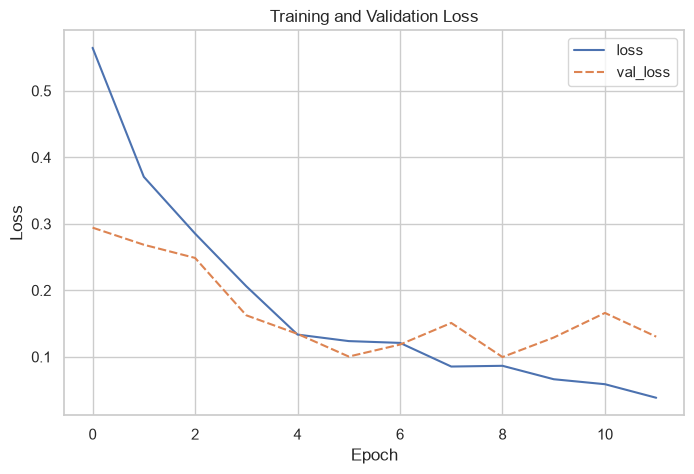

In [8]:
# Plot training and validation loss across epochs to check for overfitting
history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=history_df[["loss", "val_loss"]], ax=ax)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
plt.show()

## Evaluate on the Validation Set

The trained model predicts a fraud probability for every validation posting. Thresholding at 0.5 produces the classification report; the raw probabilities are used for `roc_auc_score`, since ROC-AUC only needs postings ranked from least to most likely fraudulent, not calibrated probabilities.

In [9]:
# Predict fraud probabilities on the validation set, then threshold at 0.5 for the
# classification report
validation_probabilities = model.predict(X_val_padded).ravel()
validation_predictions = (validation_probabilities >= 0.5).astype(int)

print(classification_report(y_val, validation_predictions))
print(f"ROC-AUC: {roc_auc_score(y_val, validation_probabilities):.4f}")

 1/84 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step

 3/84 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step  

 5/84 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step

 7/84 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step

 9/84 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step

...

81/84 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

83/84 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step


              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2552
           1       0.78      0.70      0.74       130

    accuracy                           0.98      2682
   macro avg       0.88      0.85      0.86      2682
weighted avg       0.98      0.98      0.98      2682

ROC-AUC: 0.9358


The confusion matrix is plotted in the same style as `04_modelling_classical.ipynb`'s two classical variants, so all three models' false positives and false negatives can be compared side by side in `06_evaluation.ipynb`.

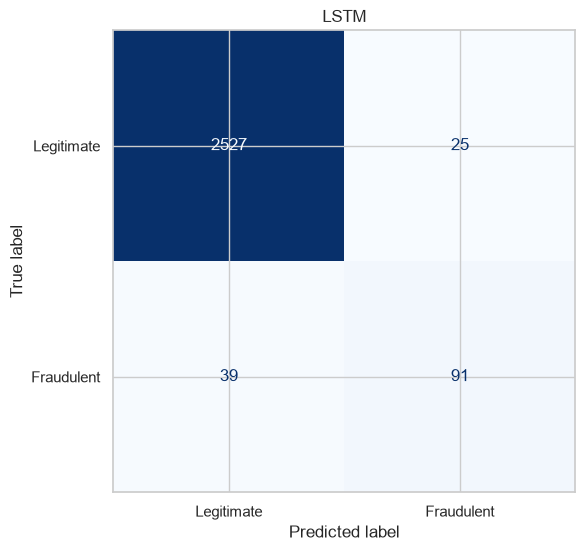

In [10]:
# Plot the confusion matrix, matching the style used for both classical models in
# 04_modelling_classical.ipynb so the figures are directly comparable
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_val, validation_predictions, display_labels=["Legitimate", "Fraudulent"], ax=ax, colorbar=False, cmap="Blues")
ax.set_title("LSTM")
plt.show()

## Summary

- Reproduced `04_modelling_classical.ipynb`'s exact split (same `RANDOM_STATE`, same two `train_test_split` calls), confirmed by matching row counts and fraud rates across training, validation, and test sets (12,516 / 2,682 / 2,682 rows; 4.84% / 4.85% / 4.85% fraudulent).
- Tokenized the training text only into a 5,000-word vocabulary and padded every sequence to 366 words, the median length of a training posting. The embedding layer masks the padding so the LSTM only reads real words.
- Trained a small `Embedding` → `LSTM` → `Dense` model (353,089 parameters) with class weights matching the classical models' `class_weight="balanced"` and clipped gradients, stopping early once validation loss stopped improving.
- On the validation set, the LSTM reaches 0.78 precision, 0.70 recall, and 0.74 F1 on the fraudulent class, with a ROC-AUC of 0.9358. Both classical variants from `04_modelling_classical.ipynb` outperform it on every one of these numbers (Logistic Regression: 0.78 precision, 0.91 recall, 0.84 F1, 0.9944 ROC-AUC; Linear SVM: 0.85 precision, 0.85 recall, 0.85 F1, 0.9927 ROC-AUC). With only 12,516 training rows and roughly 606 fraudulent examples to learn from, the LSTM has far less signal to work with than TF-IDF plus metadata gives the classical models, which matches the expectation set in `CLAUDE.md` that the classical model would likely be favoured.
- The test set remains untouched. `06_evaluation.ipynb` brings all three models together, decides which one is deployed based on test-set performance, and saves the winner to `models/deployed_pipeline.joblib`.